In [1]:
# LAKUKAN IMPORT UNTUK SEMUA LIBRARY YANG DIBUTUHKAN

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy
import folium
import folium
from folium.plugins import HeatMap
import contextily as ctx

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# MULAI DENGAN MEMBACA DATA YANG DIBUTUHKAN

In [28]:
df = pd.read_csv("Data Fix ISPU DKI JAKARTA.csv")

In [29]:
df = pd.read_csv("Data Fix ISPU DKI JAKARTA.csv", sep=';')

In [167]:
print(df)

       Tanggal Lokasi_SPKU  PM_10  PM_25  SO2  CO  O3  NO2  Max     Kategori  \
0   2022-01-01        DKI4     57     85   48  13  34   18   85       SEDANG   
1   2022-01-31        DKI4     72    119   58  44  53   44  119  TIDAK SEHAT   
2   2022-01-30        DKI4     75    129   53  25  59   50  129  TIDAK SEHAT   
3   2022-01-29        DKI4     65    120   52  30  52   46  120  TIDAK SEHAT   
4   2022-01-28        DKI3     63     84   52  12  60   28   84       SEDANG   
..         ...         ...    ...    ...  ...  ..  ..  ...  ...          ...   
358 2022-12-26        DKI2     43     62   58  54  25   27   62       SEDANG   
359 2022-12-27        DKI2     36     47   58  42  20   18   58       SEDANG   
360 2022-12-28        DKI3     46     66   57  41  15   19   66       SEDANG   
361 2022-12-29        DKI2     23     50   57  12  16   15   57       SEDANG   
362 2022-12-30        DKI4     40     64   57  21  17   24   64       SEDANG   

    Critical        Stasiun  Latitude  

In [ ]:
# MELAKUKAN PENGECEKAN DATA

In [31]:
df.head()

,Tanggal,Lokasi_SPKU,PM_10,PM_25,SO2,CO,O3,NO2,Max,Kategori,Critical,Stasiun,Latitude,Longitude
0,01/01/2022,DKI4,57,85,48,13,34,18,85,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
1,31/01/2022,DKI4,72,119,58,44,53,44,119,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
2,30/01/2022,DKI4,75,129,53,25,59,50,129,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
3,29/01/2022,DKI4,65,120,52,30,52,46,120,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
4,28/01/2022,DKI3,63,84,52,12,60,28,84,SEDANG,"PM2,5",Jagakarsa,-6.3346,106.8232


In [32]:
df.info

<bound method DataFrame.info of         Tanggal Lokasi_SPKU  PM_10  PM_25  SO2  CO  O3  NO2  Max     Kategori  \
0    01/01/2022        DKI4     57     85   48  13  34   18   85       SEDANG   
1    31/01/2022        DKI4     72    119   58  44  53   44  119  TIDAK SEHAT   
2    30/01/2022        DKI4     75    129   53  25  59   50  129  TIDAK SEHAT   
3    29/01/2022        DKI4     65    120   52  30  52   46  120  TIDAK SEHAT   
4    28/01/2022        DKI3     63     84   52  12  60   28   84       SEDANG   
..          ...         ...    ...    ...  ...  ..  ..  ...  ...          ...   
358  26/12/2022        DKI2     43     62   58  54  25   27   62       SEDANG   
359  27/12/2022        DKI2     36     47   58  42  20   18   58       SEDANG   
360  28/12/2022        DKI3     46     66   57  41  15   19   66       SEDANG   
361  29/12/2022        DKI2     23     50   57  12  16   15   57       SEDANG   
362  30/12/2022        DKI4     40     64   57  21  17   24   64       SEDANG

In [33]:
df.describe()

,PM_10,PM_25,SO2,CO,O3,NO2,Max,Latitude,Longitude
count,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000
mean,59.826446,92.975207,47.914601,18.338843,57.333333,28.724518,93.892562,-6.273489,106.886886
std,13.362360,24.463457,4.557900,6.982481,23.340304,8.660645,24.476441,0.049441,0.040039
min,23.000000,40.000000,37.000000,7.000000,15.000000,6.000000,49.000000,-6.334600,106.761800
25%,52.000000,75.000000,44.000000,14.000000,39.000000,23.000000,76.000000,-6.290700,106.903500
50%,60.000000,92.000000,49.000000,17.000000,54.000000,28.000000,93.000000,-6.290700,106.903500
75%,68.500000,111.000000,51.000000,21.000000,71.500000,33.500000,111.500000,-6.290700,106.903500
max,95.000000,165.000000,62.000000,55.000000,181.000000,52.000000,181.000000,-6.158900,106.905000


In [34]:
df.isnull().sum()

Tanggal        0
Lokasi_SPKU    0
PM_10          0
PM_25          0
SO2            0
CO             0
O3             0
NO2            0
Max            0
Kategori       0
Critical       0
Stasiun        0
Latitude       0
Longitude      0
dtype: int64

In [35]:
df.head(1)

,Tanggal,Lokasi_SPKU,PM_10,PM_25,SO2,CO,O3,NO2,Max,Kategori,Critical,Stasiun,Latitude,Longitude
0,01/01/2022,DKI4,57,85,48,13,34,18,85,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035


In [46]:
df['Tanggal'] = pd.to_datetime(
    df['Tanggal'],
    dayfirst=True
)

In [ ]:
# MELAKUKAN CLEANING DATA

In [199]:
df_sampel1 = df.rename(columns={'Tanggal':'tanggal', 'Lokasi_SPKU':'location', 'PM25':'PM_2.5', 'Kategori':'kategori', 'Stasiun':'stasiun', 'Latitude':'latitude', 'Longitude':'longitude'})

In [200]:
df_sampel1 = df.rename(columns={'PM_25':'PM_2.5'})

In [201]:
df_sampel1 = df.rename(columns={'Lokasi_SPKU':'location'})

In [202]:
df_sampel1 = df.rename(columns={'Tanggal':'tanggal'})

In [203]:
df_sampel1 = df.rename(columns={'Stasiun':'stasiun'})

In [204]:
df_sampel1 = df.rename(columns={'Kategori':'kategori'})

In [205]:
df_sampel1 = df.rename(columns={'Latitude':'latitude'})

In [206]:
df_sampel1 = df.rename(columns={'Longitude':'longitude'})

In [207]:
print(df_sampel1)

       Tanggal Lokasi_SPKU  PM_10  PM_25  SO2  CO  O3  NO2  Max     Kategori  \
0   2022-01-01        DKI4     57     85   48  13  34   18   85       SEDANG   
1   2022-01-31        DKI4     72    119   58  44  53   44  119  TIDAK SEHAT   
2   2022-01-30        DKI4     75    129   53  25  59   50  129  TIDAK SEHAT   
3   2022-01-29        DKI4     65    120   52  30  52   46  120  TIDAK SEHAT   
4   2022-01-28        DKI3     63     84   52  12  60   28   84       SEDANG   
..         ...         ...    ...    ...  ...  ..  ..  ...  ...          ...   
358 2022-12-26        DKI2     43     62   58  54  25   27   62       SEDANG   
359 2022-12-27        DKI2     36     47   58  42  20   18   58       SEDANG   
360 2022-12-28        DKI3     46     66   57  41  15   19   66       SEDANG   
361 2022-12-29        DKI2     23     50   57  12  16   15   57       SEDANG   
362 2022-12-30        DKI4     40     64   57  21  17   24   64       SEDANG   

    Critical        Stasiun  Latitude  

In [208]:
df_sampel = df_sampel1.sort_values(by='Tanggal')

In [209]:
print(df_sampel)

       Tanggal Lokasi_SPKU  PM_10  PM_25  SO2  CO  O3  NO2  Max     Kategori  \
0   2022-01-01        DKI4     57     85   48  13  34   18   85       SEDANG   
30  2022-01-02        DKI4     40     70   45  10  36   11   70       SEDANG   
29  2022-01-03        DKI4     49     80   49  13  37   21   80       SEDANG   
28  2022-01-04        DKI4     59    102   51  14  51   26  102  TIDAK SEHAT   
27  2022-01-05        DKI4     95    165   53  18  55   32  165  TIDAK SEHAT   
..         ...         ...    ...    ...  ...  ..  ..  ...  ...          ...   
358 2022-12-26        DKI2     43     62   58  54  25   27   62       SEDANG   
359 2022-12-27        DKI2     36     47   58  42  20   18   58       SEDANG   
360 2022-12-28        DKI3     46     66   57  41  15   19   66       SEDANG   
361 2022-12-29        DKI2     23     50   57  12  16   15   57       SEDANG   
362 2022-12-30        DKI4     40     64   57  21  17   24   64       SEDANG   

    Critical        Stasiun  Latitude  

In [172]:
df_sampel['tanggal'] = pd.to_datetime(
    df_sampel['tanggal'],
    dayfirst=True
)

In [ ]:
# MELAKUKAN EKSPLORASI UNTUK DATA YANG SUDAH DI CLEANING

In [173]:
df_sampel.head()

,tanggal,location,PM_10,PM_25,SO2,CO,O3,NO2,Max,kategori,Critical,stasiun,latitude,longitude
0,2022-01-01,DKI4,57,85,48,13,34,18,85,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
30,2022-01-02,DKI4,40,70,45,10,36,11,70,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
29,2022-01-03,DKI4,49,80,49,13,37,21,80,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
28,2022-01-04,DKI4,59,102,51,14,51,26,102,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
27,2022-01-05,DKI4,95,165,53,18,55,32,165,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035


In [174]:
df_sampel.rename(columns={'PM_25':'PM_2.5'})

,tanggal,location,PM_10,PM_2.5,SO2,CO,O3,NO2,Max,kategori,Critical,stasiun,latitude,longitude
0,2022-01-01,DKI4,57,85,48,13,34,18,85,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
30,2022-01-02,DKI4,40,70,45,10,36,11,70,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
29,2022-01-03,DKI4,49,80,49,13,37,21,80,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
28,2022-01-04,DKI4,59,102,51,14,51,26,102,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
27,2022-01-05,DKI4,95,165,53,18,55,32,165,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,2022-12-26,DKI2,43,62,58,54,25,27,62,SEDANG,"PM2,5",Kelapa Gading,-6.1589,106.9050
359,2022-12-27,DKI2,36,47,58,42,20,18,58,SEDANG,SO2,Kelapa Gading,-6.1589,106.9050
360,2022-12-28,DKI3,46,66,57,41,15,19,66,SEDANG,"PM2,5",Jagakarsa,-6.3346,106.8232
361,2022-12-29,DKI2,23,50,57,12,16,15,57,SEDANG,SO2,Kelapa Gading,-6.1589,106.9050


In [117]:
df_sampeel = df_sampel.rename(columns={'PM_25':'PM_2.5'})

In [118]:
df_sampeel.info()

<class 'pandas.DataFrame'>
Index: 363 entries, 0 to 362
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   tanggal    363 non-null    datetime64[us]
 1   location   363 non-null    str           
 2   PM_10      363 non-null    int64         
 3   PM_2.5     363 non-null    int64         
 4   SO2        363 non-null    int64         
 5   CO         363 non-null    int64         
 6   O3         363 non-null    int64         
 7   NO2        363 non-null    int64         
 8   Max        363 non-null    int64         
 9   kategori   363 non-null    str           
 10  Critical   363 non-null    str           
 11  stasiun    363 non-null    str           
 12  latitude   363 non-null    float64       
 13  longitude  363 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(7), str(4)
memory usage: 42.5 KB


In [119]:
df_sampeel.isnull().sum()

tanggal      0
location     0
PM_10        0
PM_2.5       0
SO2          0
CO           0
O3           0
NO2          0
Max          0
kategori     0
Critical     0
stasiun      0
latitude     0
longitude    0
dtype: int64

In [120]:
df_sampeel.describe()

,tanggal,PM_10,PM_2.5,SO2,CO,O3,NO2,Max,latitude,longitude
count,363,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000
mean,2022-07-01 14:04:57.520661,59.826446,92.975207,47.914601,18.338843,57.333333,28.724518,93.892562,-6.273489,106.886886
min,2022-01-01 00:00:00,23.000000,40.000000,37.000000,7.000000,15.000000,6.000000,49.000000,-6.334600,106.761800
25%,2022-04-01 12:00:00,52.000000,75.000000,44.000000,14.000000,39.000000,23.000000,76.000000,-6.290700,106.903500
50%,2022-07-02 00:00:00,60.000000,92.000000,49.000000,17.000000,54.000000,28.000000,93.000000,-6.290700,106.903500
75%,2022-09-30 12:00:00,68.500000,111.000000,51.000000,21.000000,71.500000,33.500000,111.500000,-6.290700,106.903500
max,2022-12-30 00:00:00,95.000000,165.000000,62.000000,55.000000,181.000000,52.000000,181.000000,-6.158900,106.905000
std,NaN,13.362360,24.463457,4.557900,6.982481,23.340304,8.660645,24.476441,0.049441,0.040039


In [121]:
df_sampeel.head(40)

,tanggal,location,PM_10,PM_2.5,SO2,CO,O3,NO2,Max,kategori,Critical,stasiun,latitude,longitude
0,2022-01-01,DKI4,57,85,48,13,34,18,85,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
30,2022-01-02,DKI4,40,70,45,10,36,11,70,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
29,2022-01-03,DKI4,49,80,49,13,37,21,80,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
28,2022-01-04,DKI4,59,102,51,14,51,26,102,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
27,2022-01-05,DKI4,95,165,53,18,55,32,165,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
26,2022-01-06,DKI4,73,117,53,16,48,42,117,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
25,2022-01-07,DKI4,71,113,48,22,38,41,113,TIDAK SEHAT,"PM2,5",Lubang Buaya,-6.2907,106.9035
24,2022-01-08,DKI4,55,77,52,17,41,29,77,SEDANG,"PM2,5",Lubang Buaya,-6.2907,106.9035
23,2022-01-09,DKI3,56,82,52,14,39,27,82,SEDANG,"PM2,5",Jagakarsa,-6.3346,106.8232
22,2022-01-10,DKI3,60,87,51,13,36,26,87,SEDANG,"PM2,5",Jagakarsa,-6.3346,106.8232


In [ ]:
# TAHAPAN VISUALISASI DATA

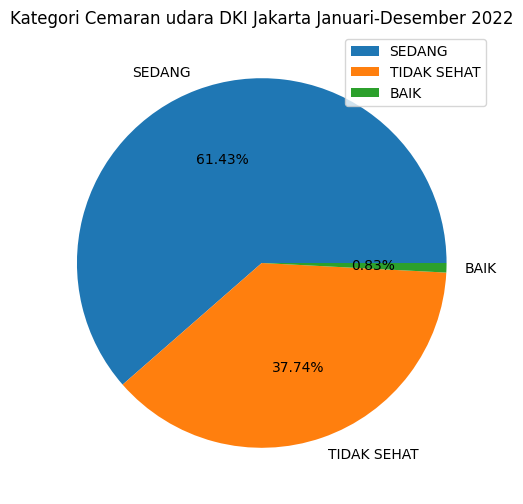

In [122]:
plt.figure(figsize=(8,6))

plt.pie(df_sampeel.kategori.value_counts(), labels=df_sampeel.kategori.value_counts().index, autopct='%.2f%%')

plt.title('Kategori Cemaran udara DKI Jakarta Januari-Desember 2022')
plt.legend()
plt.show()

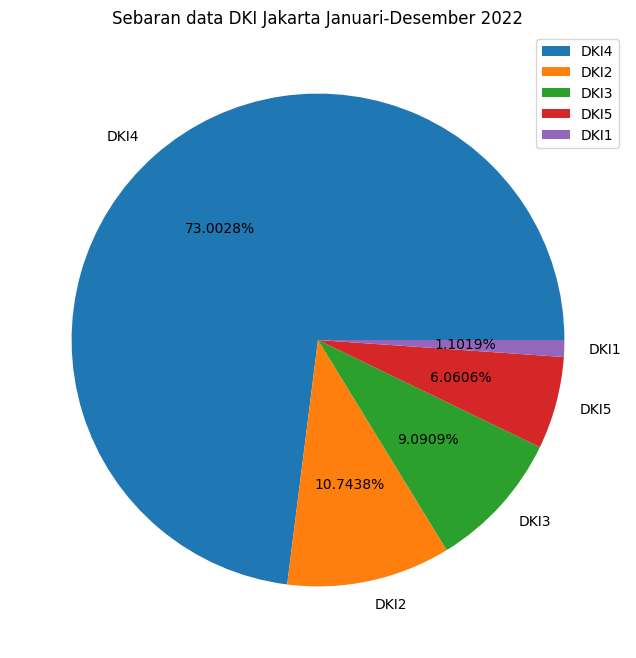

In [124]:
plt.figure(figsize=(8,8))

plt.pie(df_sampeel.location.value_counts(), labels=df_sampeel.location.value_counts().index, autopct='%.4f%%')
plt.title('Sebaran data DKI Jakarta Januari-Desember 2022')
plt.legend()
plt.show()

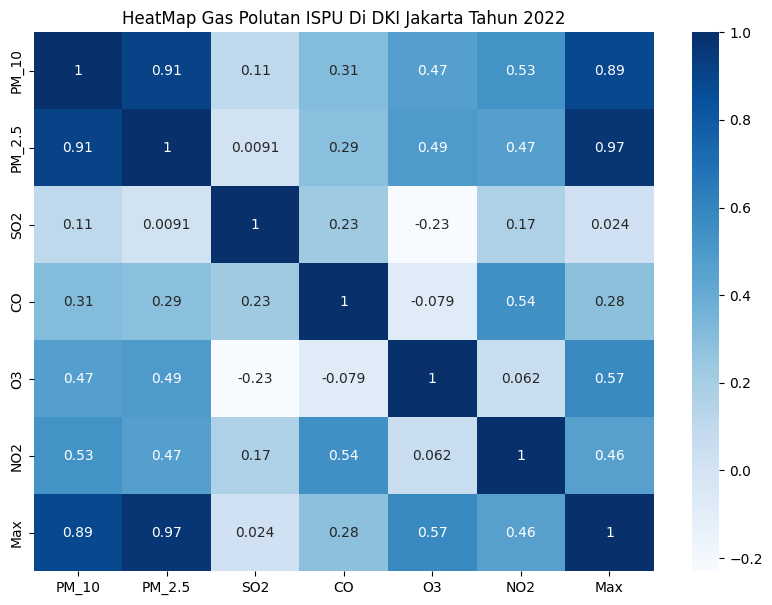

In [143]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_sampeel[['PM_10','PM_2.5','SO2','CO','O3','NO2','Max']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('HeatMap Gas Polutan ISPU Di DKI Jakarta Tahun 2022')
plt.show()

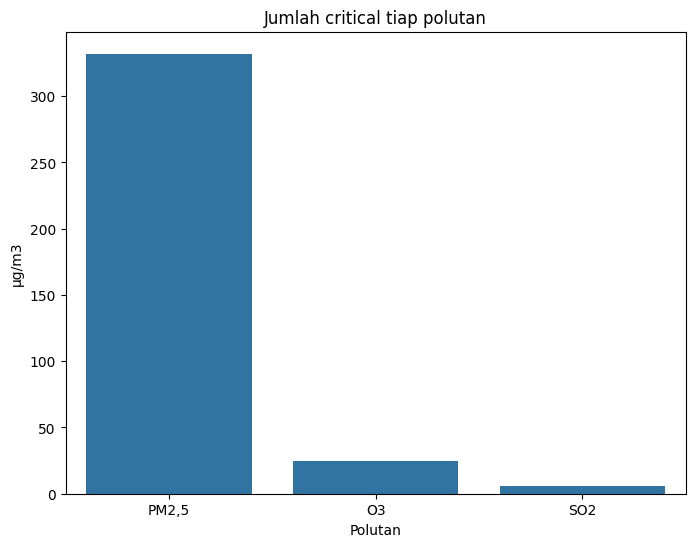

In [125]:
plt.figure(figsize=(8,6))

sns.barplot(x=df_sampeel.Critical.value_counts().index, y=df_sampeel.Critical.value_counts())

plt.title('Jumlah critical tiap polutan')
plt.xlabel('Polutan')
plt.ylabel('µg/m3')
plt.show()

In [159]:
df_resample1 = (
    df_sampeel
    .set_index('tanggal')
    [['PM_10','PM_2.5','SO2','CO','O3','NO2','Max']]
    .resample('D')
    .mean()
    .reset_index()
)

In [160]:
df_resample1

,tanggal,PM_10,PM_2.5,SO2,CO,O3,NO2,Max
0,2022-01-01,57.0,85.0,48.0,13.0,34.0,18.0,85.0
1,2022-01-02,40.0,70.0,45.0,10.0,36.0,11.0,70.0
2,2022-01-03,49.0,80.0,49.0,13.0,37.0,21.0,80.0
3,2022-01-04,59.0,102.0,51.0,14.0,51.0,26.0,102.0
4,2022-01-05,95.0,165.0,53.0,18.0,55.0,32.0,165.0
...,...,...,...,...,...,...,...,...
359,2022-12-26,43.0,62.0,58.0,54.0,25.0,27.0,62.0
360,2022-12-27,36.0,47.0,58.0,42.0,20.0,18.0,58.0
361,2022-12-28,46.0,66.0,57.0,41.0,15.0,19.0,66.0
362,2022-12-29,23.0,50.0,57.0,12.0,16.0,15.0,57.0


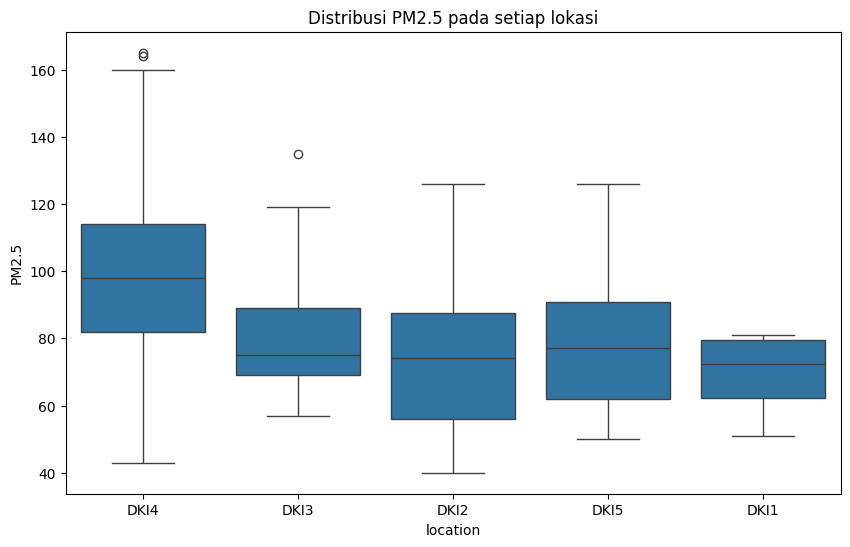

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_sampeel,
    x="location",
    y="PM_2.5"
)

plt.title("Distribusi PM2.5 pada setiap lokasi")
plt.xlabel("location")
plt.ylabel("PM2.5")

plt.show()

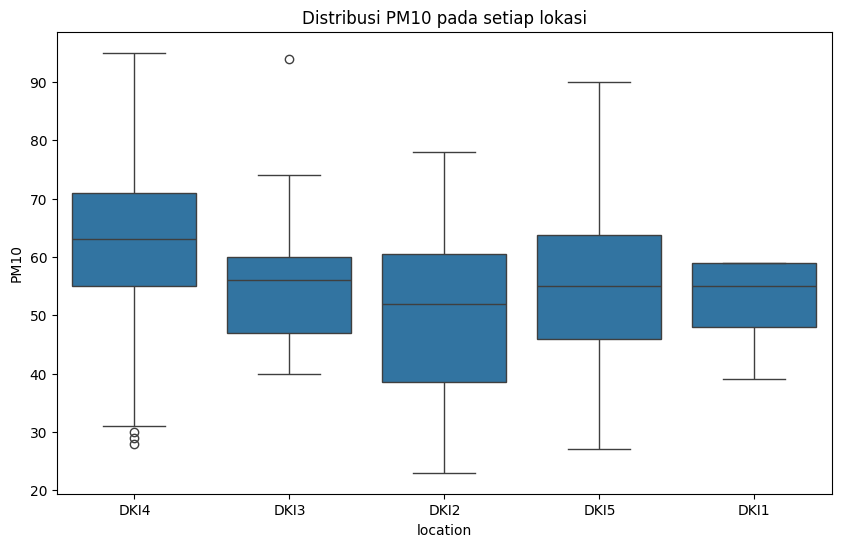

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_sampeel,
    x="location",
    y="PM_10"
)

plt.title("Distribusi PM10 pada setiap lokasi")
plt.xlabel("location")
plt.ylabel("PM10")

plt.show()

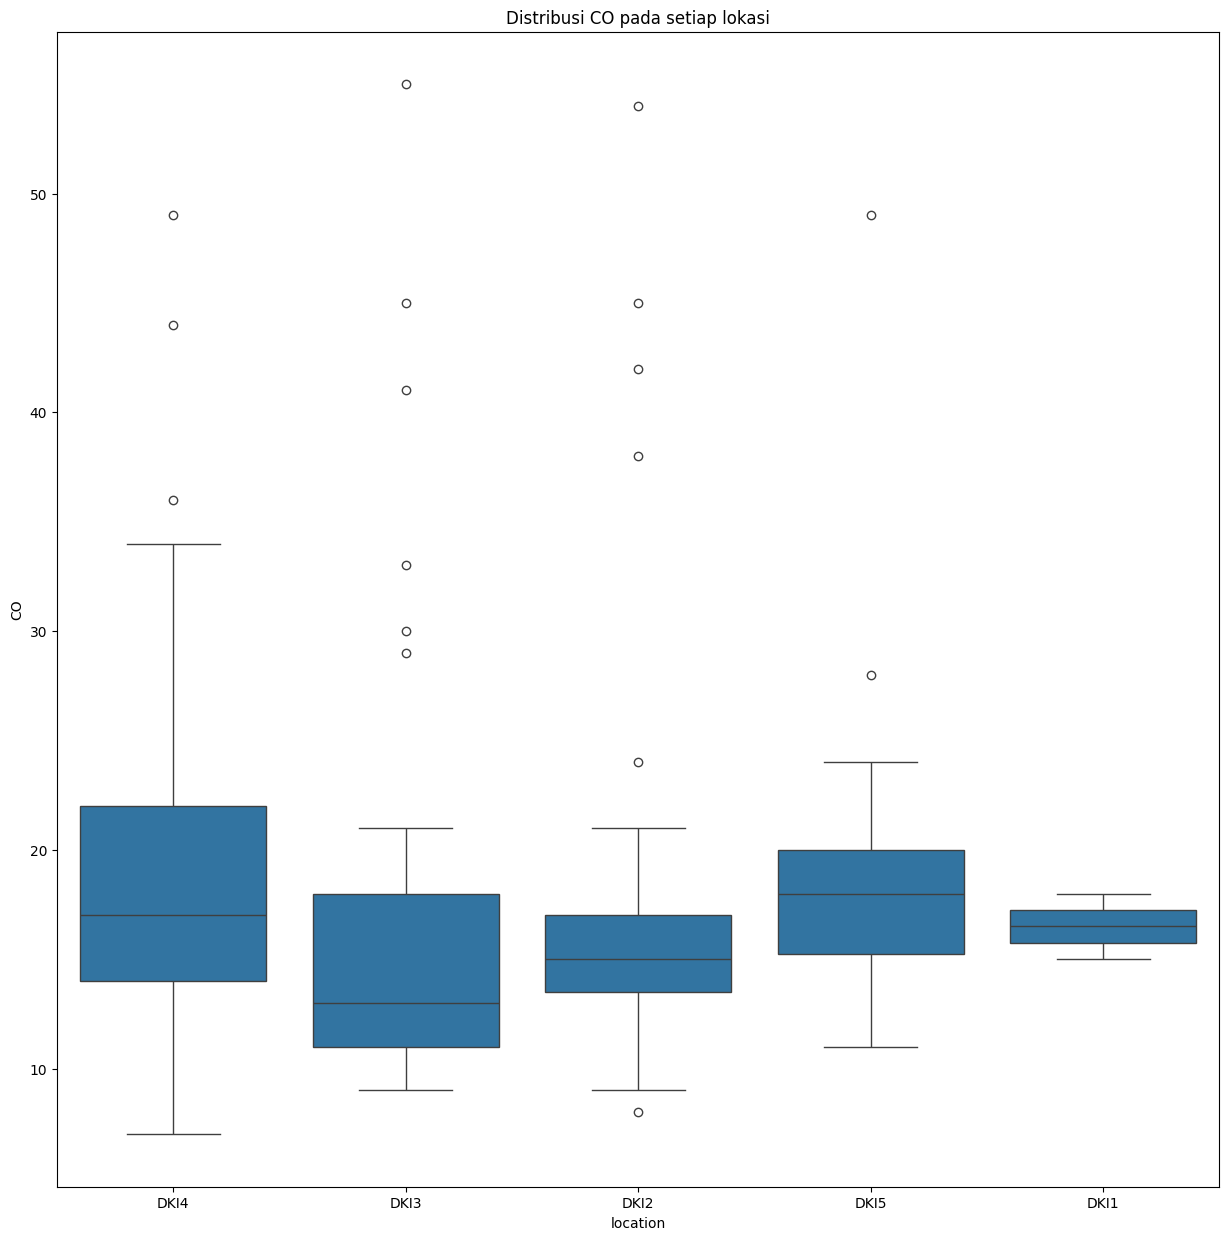

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

sns.boxplot(
    data=df_sampeel,
    x="location",
    y="CO"
)

plt.title("Distribusi CO pada setiap lokasi")
plt.xlabel("location")
plt.ylabel("CO")

plt.show()

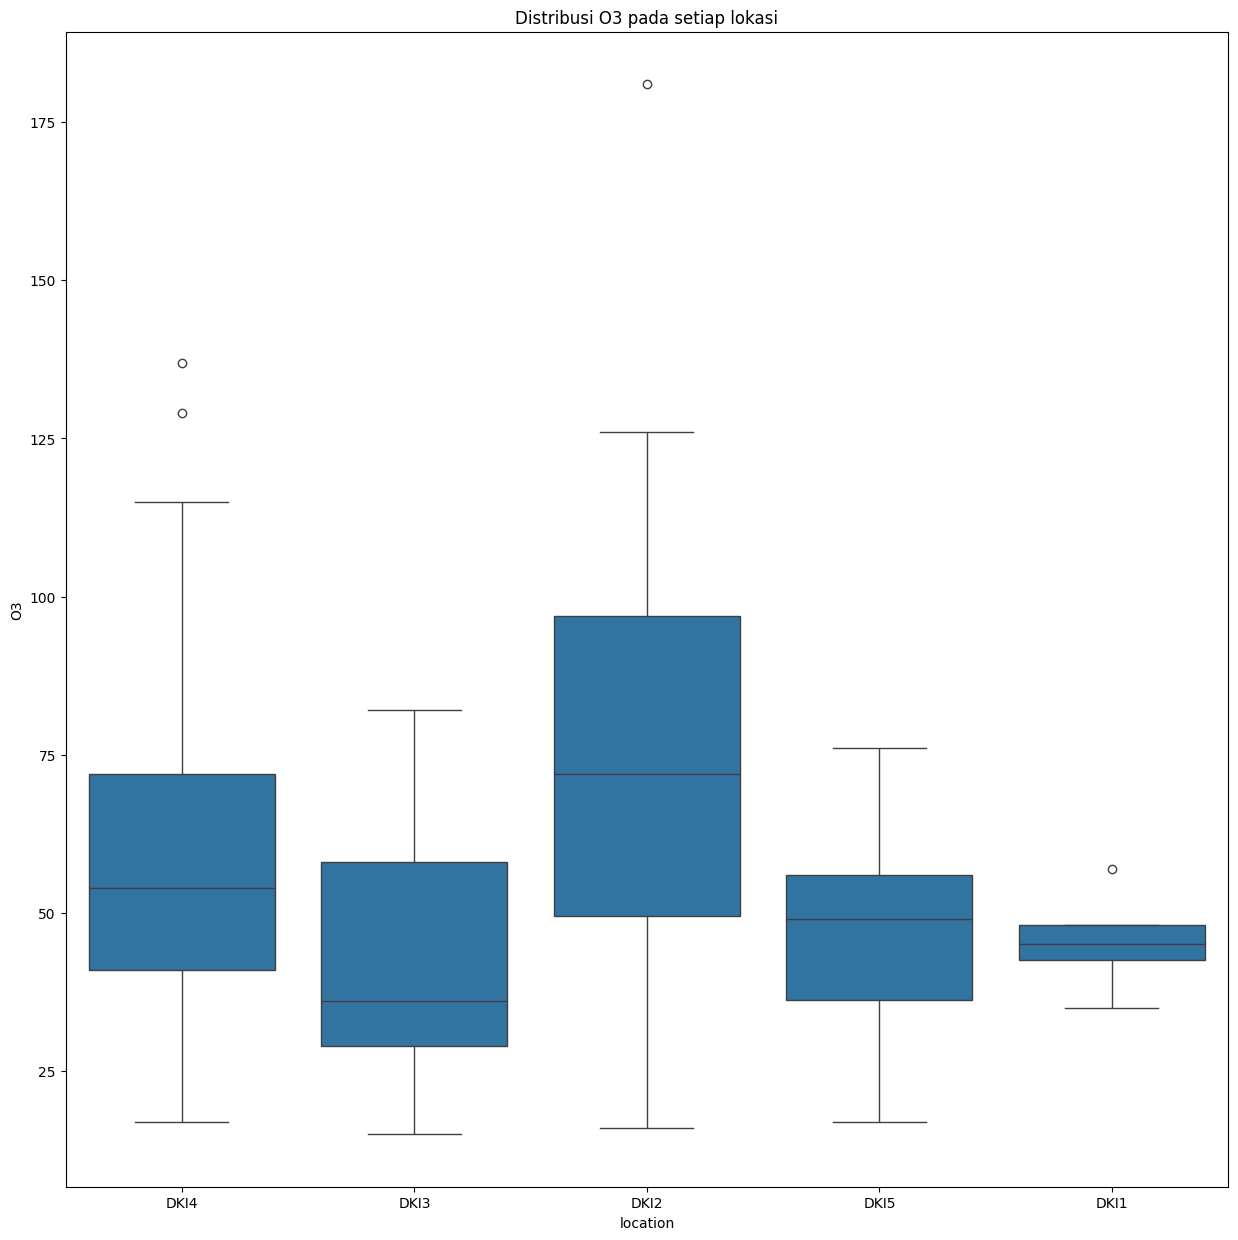

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

sns.boxplot(
    data=df_sampeel,
    x="location",
    y="O3"
)

plt.title("Distribusi O3 pada setiap lokasi")
plt.xlabel("location")
plt.ylabel("O3")

plt.show()

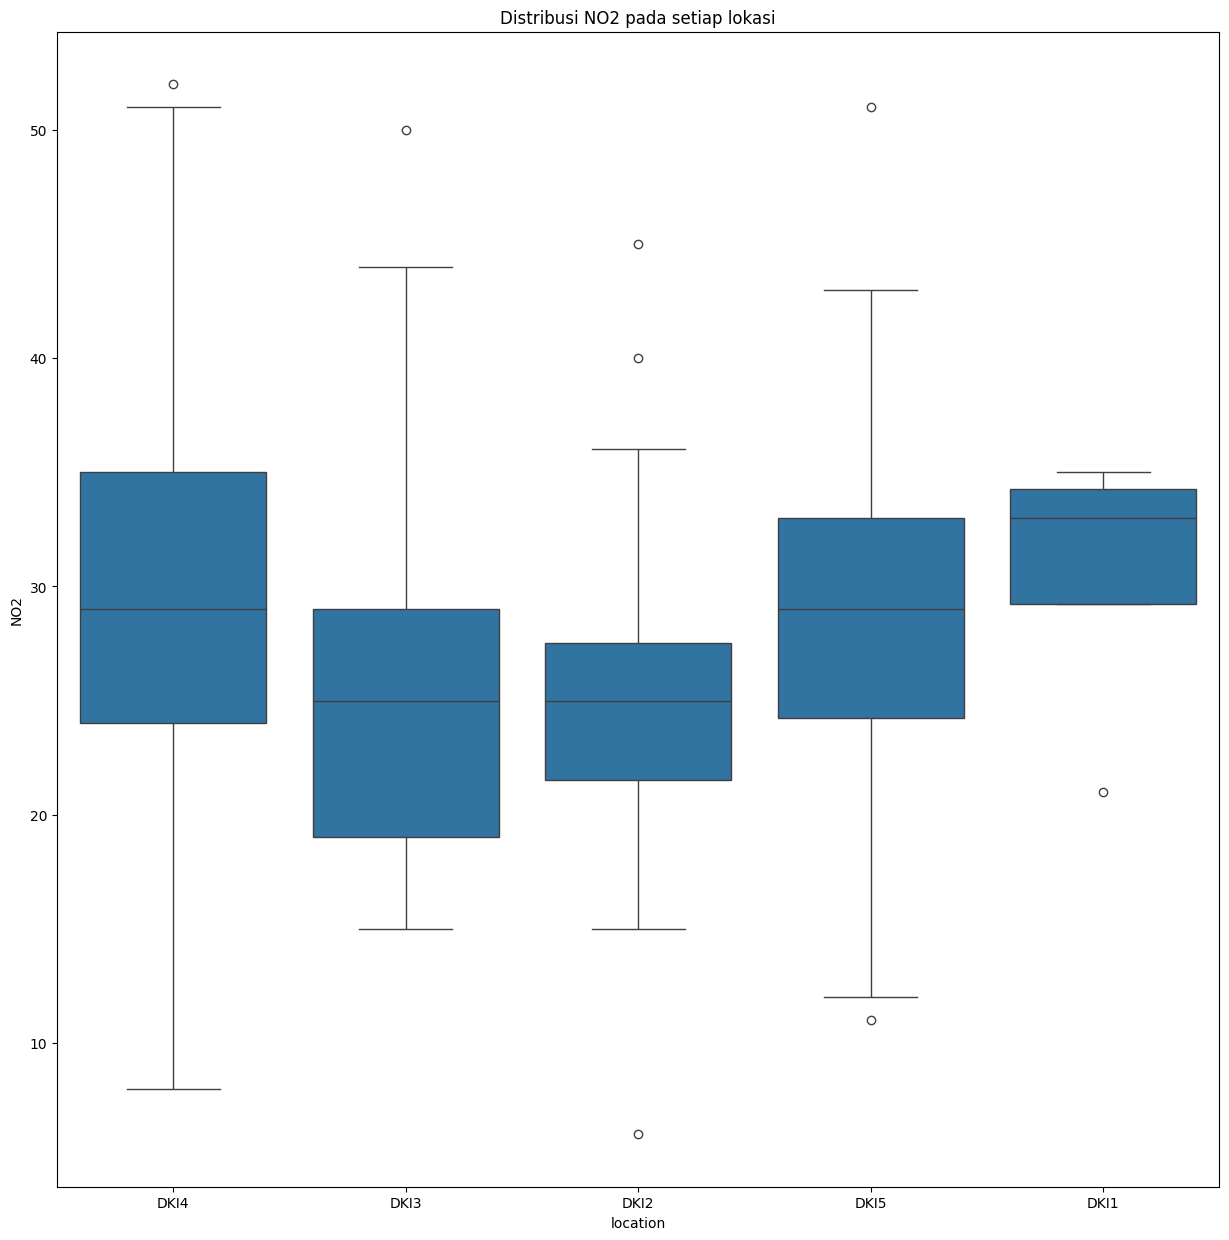

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

sns.boxplot(
    data=df_sampeel,
    x="location",
    y="NO2"
)

plt.title("Distribusi NO2 pada setiap lokasi")
plt.xlabel("location")
plt.ylabel("NO2")

plt.show()

In [77]:
print(df_resample1.head())
print(df_resample1.columns)

     tanggal  PM_10  PM_2.5   SO2    CO    O3   NO2    Max
0 2022-01-01   57.0    85.0  48.0  13.0  34.0  18.0   85.0
1 2022-01-02   40.0    70.0  45.0  10.0  36.0  11.0   70.0
2 2022-01-03   49.0    80.0  49.0  13.0  37.0  21.0   80.0
3 2022-01-04   59.0   102.0  51.0  14.0  51.0  26.0  102.0
4 2022-01-05   95.0   165.0  53.0  18.0  55.0  32.0  165.0
Index(['tanggal', 'PM_10', 'PM_2.5', 'SO2', 'CO', 'O3', 'NO2', 'Max'], dtype='str')


<Axes: xlabel='tanggal'>

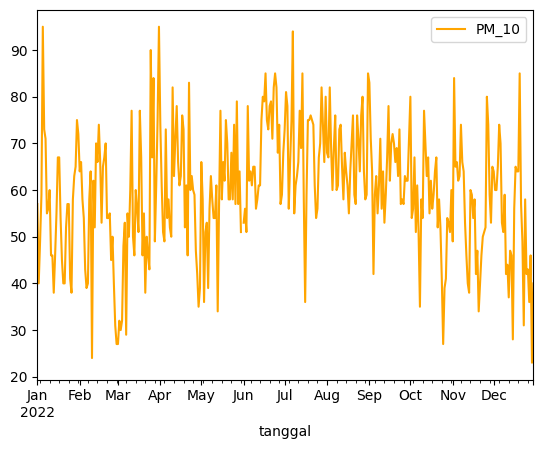

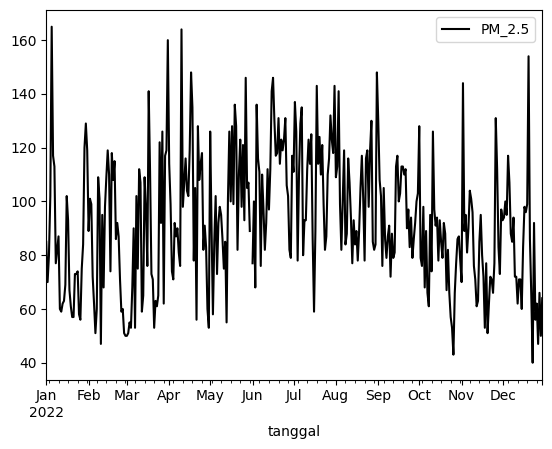

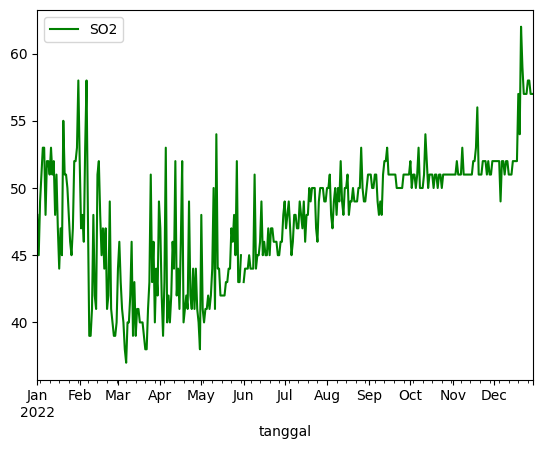

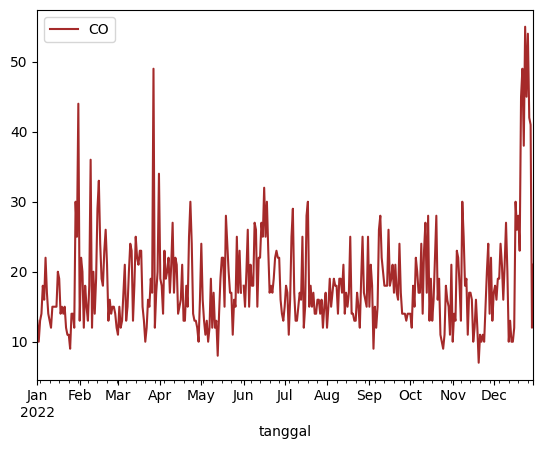

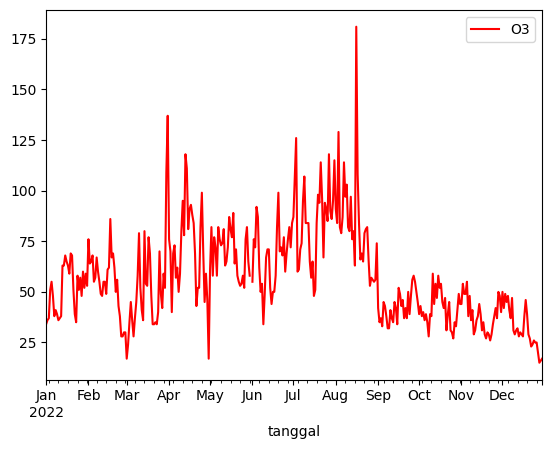

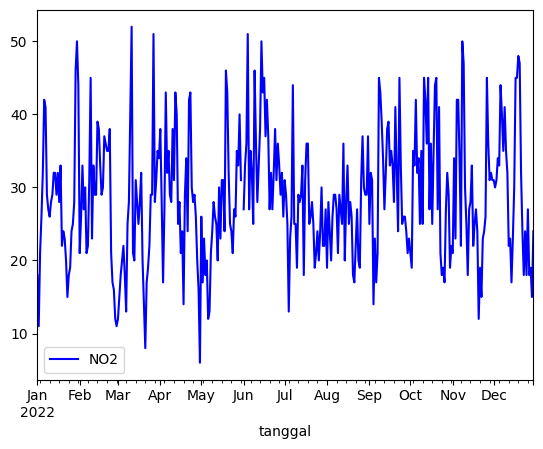

In [78]:
df_resample1.plot(x='tanggal', y='PM_10', kind='line', color='orange')
df_resample1.plot(x='tanggal', y='PM_2.5', kind='line', color='black')
df_resample1.plot(x='tanggal', y='SO2', kind='line', color='green')
df_resample1.plot(x='tanggal', y='CO', kind='line', color='brown')
df_resample1.plot(x='tanggal', y='O3', kind='line', color='red')
df_resample1.plot(x='tanggal', y='NO2', kind='line', color='blue')

In [150]:
df_agg = df_sampeel.copy()

pollutant = ['PM_10', 'PM_2.5', 'SO2', 'CO', 'O3', 'NO2']

df_agg = pd.pivot_table(data=df_agg, index=['location'], values=pollutant, aggfunc='mean').round().reset_index()

,location,CO,NO2,O3,PM_10,PM_2.5,SO2
0,DKI1,16.0,30.0,46.0,52.0,69.0,53.0
1,DKI2,18.0,25.0,73.0,50.0,74.0,48.0
2,DKI3,18.0,26.0,44.0,56.0,80.0,50.0
3,DKI4,18.0,30.0,58.0,62.0,99.0,48.0
4,DKI5,19.0,29.0,47.0,55.0,80.0,46.0


In [ ]:
# MELIHAT DISTRIBUSI UNTUK MASING-MASING DKI 

In [ ]:
# EDA (EXPLORATION DATA ANALYST)

In [166]:
print(df_sampeel)

       tanggal location  PM_10  PM_2.5  SO2  CO  O3  NO2  Max kategori  \
0   2022-01-01     DKI4     57      85   48  13  34   18   85      NaN   
30  2022-01-02     DKI4     40      70   45  10  36   11   70      NaN   
29  2022-01-03     DKI4     49      80   49  13  37   21   80      NaN   
28  2022-01-04     DKI4     59     102   51  14  51   26  102      NaN   
27  2022-01-05     DKI4     95     165   53  18  55   32  165      NaN   
..         ...      ...    ...     ...  ...  ..  ..  ...  ...      ...   
358 2022-12-26     DKI2     43      62   58  54  25   27   62      NaN   
359 2022-12-27     DKI2     36      47   58  42  20   18   58      NaN   
360 2022-12-28     DKI3     46      66   57  41  15   19   66      NaN   
361 2022-12-29     DKI2     23      50   57  12  16   15   57      NaN   
362 2022-12-30     DKI4     40      64   57  21  17   24   64      NaN   

    Critical        stasiun  latitude  longitude  
0      PM2,5   Lubang Buaya   -6.2907   106.9035  
30     PM